# Adaptive MACD + Bollinger Strategy (BTC & ETH)

Strategy definitions:
- `MACD`: a trend-following long/flat rule based on the MACD line crossing its signal line
- `Bollinger Bands`: a symmetric mean-reversion rule that buys below the lower band, sells above the upper band, and exits at the rolling mean
- `Adaptive switching`: uses MACD in `TREND` regimes and Bollinger in `MEAN_REVERSION` regimes

### Section 1: Data Cleaning and Manipulation

In [148]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)


In [149]:
eth_macd=pd.read_csv('eth_macd_18_50_13_post_trade_table.csv',parse_dates=True,index_col=0)
btc_macd=pd.read_csv('btc_macd_16_20_15_post_trade_table.csv',parse_dates=True,index_col=0)

eth_macd.rename(columns={
    'trade': 'macd_trade',
    'position': 'macd_position',
    'trade_action': 'macd_trade_action'
}, inplace=True)

btc_macd.rename(columns={
    'trade': 'macd_trade',
    'position': 'macd_position',
    'trade_action': 'macd_trade_action'
}, inplace=True)

eth_macd.head(), btc_macd.head()

(                 price  log_return  macd_trade macd_trade_action  macd_position
 date                                                                           
 2018-01-01  772.640991    0.000000           0              hold              0
 2018-01-02  884.443970    0.135145           0              hold              0
 2018-01-03  962.719971    0.084803           1               buy              1
 2018-01-04  980.921997    0.018730           0              hold              1
 2018-01-05  997.719971    0.016980           0              hold              1,
                    price  log_return  macd_trade macd_trade_action  macd_position
 date                                                                             
 2018-01-01  13657.200195    0.000000           0              hold              0
 2018-01-02  14982.099609    0.092589           0              hold              0
 2018-01-03  15201.000000    0.014505           1               buy              1
 2018-01-04  1559

In [150]:
eth_bollinger=pd.read_csv('eth_bollinger_post_trade_table.csv',parse_dates=True,index_col=0)
btc_bollinger=pd.read_csv('btc_bollinger_post_trade_table.csv',parse_dates=True,index_col=0)

eth_bollinger.rename(columns={
    'trade': 'bollinger_trade',
    'position': 'bollinger_position',
    'trade_action': 'bollinger_trade_action'
}, inplace=True)

btc_bollinger.rename(columns={
    'trade': 'bollinger_trade',
    'position': 'bollinger_position',
    'trade_action': 'bollinger_trade_action'
}, inplace=True)

eth_bollinger.head(), btc_bollinger.head()

(               price  log_return  bollinger_trade bollinger_trade_action  bollinger_position
 date                                                                                        
 1/1/2018  772.640991    0.000000                0                   hold                   0
 2/1/2018  884.443970    0.135145                0                   hold                   0
 3/1/2018  962.719971    0.084803                0                   hold                   0
 4/1/2018  980.921997    0.018730                0                   hold                   0
 5/1/2018  997.719971    0.016980                0                   hold                   0,
                 price  log_return  bollinger_trade bollinger_trade_action  bollinger_position
 date                                                                                         
 1/1/2018  13657.20020    0.000000                0                   hold                   0
 2/1/2018  14982.09961    0.092589                0     

In [151]:
# Ensure both indices are datetime
eth_bollinger.index = pd.to_datetime(eth_bollinger.index, format='mixed', dayfirst=True)
btc_bollinger.index = pd.to_datetime(btc_bollinger.index, format='mixed', dayfirst=True)
eth_macd.index = pd.to_datetime(eth_macd.index)
btc_macd.index = pd.to_datetime(btc_macd.index)

# sort index just to be safe
eth_bollinger = eth_bollinger.sort_index()
eth_macd = eth_macd.sort_index()

btc_bollinger = btc_bollinger.sort_index()
btc_macd = btc_macd.sort_index()

# Join (ETH with ETH, BTC with BTC)
eth_combined = eth_bollinger.join(
    eth_macd.drop(columns=['price', 'log_return']),
    how='inner'
)

btc_combined = btc_bollinger.join(
    btc_macd.drop(columns=['price', 'log_return']),
    how='inner'
)

# View
eth_combined.head(), btc_combined.head()

(                 price  log_return  bollinger_trade bollinger_trade_action  bollinger_position  macd_trade macd_trade_action  \
 date                                                                                                                           
 2018-01-01  772.640991    0.000000                0                   hold                   0           0              hold   
 2018-01-02  884.443970    0.135145                0                   hold                   0           0              hold   
 2018-01-03  962.719971    0.084803                0                   hold                   0           1               buy   
 2018-01-04  980.921997    0.018730                0                   hold                   0           0              hold   
 2018-01-05  997.719971    0.016980                0                   hold                   0           0              hold   
 
             macd_position  
 date                       
 2018-01-01              0  
 2018-01

### Section 2: Trend Strength & Regime Switching

We define trend strength using a signed efficiency-ratio style measure:

$$
TS_t =
\frac{P_t - P_{t-L}}
{\sum_{i=t-L+1}^{t} \left| P_i - P_{i-1} \right|}
$$

The adaptive strategy switches regimes based on trend strength:

$$
\text{Position}_t =
\begin{cases}
\text{MACD}_t, & \text{if } TS_t > \tau \\
\text{Bollinger}_t, & \text{otherwise}
\end{cases}
$$

**where:**
- $P_t$ = price at time $t$
- $L$ = lookback window (e.g. 30)
- $\tau$ = threshold

**interpretation:**
- numerator → net directional move  
- denominator → total path length (volatility)  
- $|TS_t| \approx 1$ → strong trend  
- $TS_t \approx 0$ → choppy / mean-reverting  


In [164]:
# =========================
# Trend Strength + Adaptive Strategy
# =========================

# Parameters
L = 30
threshold = 0.1 

# ---------- ETH ----------
eth_combined['trend_strength'] = (
    (eth_combined['price'] - eth_combined['price'].shift(L)) /
    eth_combined['price'].diff().abs().rolling(L).sum()
)

eth_combined['position'] = np.where(
    eth_combined['trend_strength'].abs().fillna(0) > threshold,
    eth_combined['macd_position'],
    eth_combined['bollinger_position']
)

# ---------- BTC ----------
btc_combined['trend_strength'] = (
    (btc_combined['price'] - btc_combined['price'].shift(L)) /
    btc_combined['price'].diff().abs().rolling(L).sum()
)

btc_combined['position'] = np.where(
    btc_combined['trend_strength'].abs().fillna(0) > threshold,
    btc_combined['macd_position'],
    btc_combined['bollinger_position']
)


eth_combined['position'] = (
    eth_combined['position']
    .ffill()
    .fillna(0)
)

btc_combined['position'] = (
    btc_combined['position']
    .ffill()
    .fillna(0)
)

In [165]:
# =========================
# Sanity Checks (ETH + BTC)
# =========================

print("========== ETH ==========")
print("\nTrend Strength Stats:")
print(eth_combined['trend_strength'].describe())

print("\nQuantiles:")
print(eth_combined['trend_strength'].abs().quantile([0.5, 0.7, 0.9, 0.95]))

print("\nAdaptive Position Distribution:")
print(eth_combined['position'].value_counts(normalize=True))




========== ETH ==========

Trend Strength Stats:
count    2891.000000
mean        0.020883
std         0.268360
min        -0.696112
25%        -0.173264
50%         0.004237
75%         0.215528
max         0.757791
Name: trend_strength, dtype: float64

Quantiles:
0.50    0.195046
0.70    0.286658
0.90    0.435588
0.95    0.524156
Name: trend_strength, dtype: float64

Adaptive Position Distribution:
position
 0    0.521739
 1    0.439918
-1    0.038343
Name: proportion, dtype: float64


In [167]:
print("\n========== BTC ==========")
print("\nTrend Strength Stats:")
print(btc_combined['trend_strength'].describe())

print("\nQuantiles:")
print(btc_combined['trend_strength'].abs().quantile([0.5, 0.7, 0.9, 0.95]))

print("\nAdaptive Position Distribution:")
print(btc_combined['position'].value_counts(normalize=True))


========== BTC ==========

Trend Strength Stats:
count    2891.000000
mean        0.041078
std         0.272451
min        -0.731441
25%        -0.148688
50%         0.022928
75%         0.226599
max         0.783221
Name: trend_strength, dtype: float64

Quantiles:
0.50    0.189999
0.70    0.288943
0.90    0.461044
0.95    0.549764
Name: trend_strength, dtype: float64

Adaptive Position Distribution:
position
 0    0.533379
 1    0.425197
-1    0.041424
Name: proportion, dtype: float64


In [168]:
eth_combined['position'].value_counts(), btc_combined['position'].value_counts()

(position
  0    1524
  1    1285
 -1     112
 Name: count, dtype: int64,
 position
  0    1558
  1    1242
 -1     121
 Name: count, dtype: int64)

### Section 3 : Evaluation 

In [169]:
# ---------- ETH ----------
eth_combined['trade'] = (
    eth_combined['position'] - eth_combined['position'].shift(1)
).fillna(0)

eth_combined['trade'] = eth_combined['trade'].clip(-1, 1)


# ---------- BTC ----------
btc_combined['trade'] = (
    btc_combined['position'] - btc_combined['position'].shift(1)
).fillna(0)

btc_combined['trade'] = btc_combined['trade'].clip(-1, 1)


In [170]:
required_cols = ["price", "log_return", "position", "trade"]

print("BTC missing cols:", [c for c in required_cols if c not in btc_combined.columns])
print("ETH missing cols:", [c for c in required_cols if c not in eth_combined.columns])

BTC missing cols: []
ETH missing cols: []


In [171]:
print("BTC NaNs:\n", btc_combined[required_cols].isna().sum())
print("\nETH NaNs:\n", eth_combined[required_cols].isna().sum())

BTC NaNs:
 price         0
log_return    0
position      0
trade         0
dtype: int64

ETH NaNs:
 price         0
log_return    0
position      0
trade         0
dtype: int64


In [121]:
# ============================================================
# 1) Base preparation
# ============================================================
def prepare_post_trade_df(
    post_trade_df,
    date_col="date",
    price_col="price",
    position_col="position",
    trade_col="trade",
    log_return_col="log_return"
):
    out = post_trade_df.copy()

    if date_col in out.columns:
        out = out.sort_values(date_col).reset_index(drop=True)
    else:
        out = out.reset_index(drop=True)

    if price_col not in out.columns:
        raise ValueError(f"'{price_col}' column is required.")

    if position_col not in out.columns:
        raise ValueError(f"'{position_col}' column is required.")

    out[position_col] = out[position_col].fillna(0).astype(int)

    # asset return
    if price_col in out.columns:
        out["asset_ret"] = out[price_col].pct_change().fillna(0.0)
    elif log_return_col in out.columns:
        out["asset_ret"] = np.expm1(out[log_return_col]).fillna(0.0)
    else:
        raise ValueError(f"Need either '{price_col}' or '{log_return_col}'.")

    # trade size / turnover
    if trade_col in out.columns:
        out["trade_size"] = out[trade_col].fillna(0).abs()
    else:
        out["trade_size"] = out[position_col].diff().fillna(out[position_col]).abs()

    return out


In [172]:
btc_combined = btc_combined.reset_index()
eth_combined = eth_combined.reset_index()

In [130]:
btc_post = prepare_post_trade_df(btc_combined)
eth_post = prepare_post_trade_df(eth_combined)

In [134]:
# ============================================================
# 2) Daily marked-to-market evaluation
# ============================================================
def evaluate_daily_post_trade_df(
    post_trade_df,
    date_col="date",
    price_col="price",
    position_col="position",
    trade_col="trade",
    log_return_col="log_return",
    fee=0.0,
    rf_annual=0.03,
    trading_days=365
):
    out = prepare_post_trade_df(
        post_trade_df=post_trade_df,
        date_col=date_col,
        price_col=price_col,
        position_col=position_col,
        trade_col=trade_col,
        log_return_col=log_return_col
    )

    # gross and net daily strategy return
    out["strategy_ret_gross"] = out[position_col] * out["asset_ret"]
    out["strategy_ret_net"] = out["strategy_ret_gross"] - out["trade_size"] * fee

    # equity curve
    out["equity_curve"] = (1 + out["strategy_ret_net"]).cumprod()
    out["cumulative_pnl_series"] = out["equity_curve"] - 1

    # drawdown
    out["running_max"] = out["equity_curve"].cummax()
    out["drawdown"] = out["equity_curve"] / out["running_max"] - 1

    # summary metrics
    n = len(out)
    years = n / trading_days if trading_days > 0 else np.nan

    cumulative_pnl = out["cumulative_pnl_series"].iloc[-1]
    average_daily_pnl = out["strategy_ret_net"].mean()
    max_drawdown = out["drawdown"].min()

    annualised_return = (
        out["equity_curve"].iloc[-1] ** (1 / years) - 1
        if years > 0 else np.nan
    )

    daily_std_dev = out["strategy_ret_net"].std()
    annualised_volatility = daily_std_dev * np.sqrt(trading_days)

    rf_daily = (1 + rf_annual) ** (1 / trading_days) - 1
    excess_daily = out["strategy_ret_net"] - rf_daily

    sharpe_ratio = (
        (excess_daily.mean() / daily_std_dev) * np.sqrt(trading_days)
        if daily_std_dev > 0 else np.nan
    )

    exposure_rate = (out[position_col] != 0).mean()
    total_turnover = out["trade_size"].sum()

    daily_summary = {
        "cumulative_pnl": cumulative_pnl,
        "average_daily_pnl": average_daily_pnl,
        "max_drawdown": max_drawdown,
        "annualised_return": annualised_return,
        "sharpe_ratio_rf_3pct": sharpe_ratio,
        "daily_std_dev": daily_std_dev,
        "annualised_volatility": annualised_volatility,
        "exposure_rate": exposure_rate,
        "total_turnover": total_turnover,
    }

    return out, daily_summary


# ============================================================
# 3) Trade log helper
# ============================================================
def _make_trade_record(
    df,
    start_idx,
    end_idx,
    direction,
    fee=0.0,
    date_col="date",
    price_col="price",
    position_col="position"
):
    n = len(df)

    prev_pos = df[position_col].iloc[start_idx - 1] if start_idx > 0 else 0
    next_pos = df[position_col].iloc[end_idx + 1] if end_idx + 1 < n else 0

    partial_start = (start_idx == 0 and direction != 0)
    open_at_end = (end_idx == n - 1 and direction != 0)

    # Important convention:
    # position_t is held over the interval from t-1 to t
    # so the entry price is the PREVIOUS row's price of the first holding day
    if start_idx > 0:
        entry_date = df[date_col].iloc[start_idx - 1] if date_col in df.columns else start_idx - 1
        entry_price = df[price_col].iloc[start_idx - 1]
    else:
        entry_date = df[date_col].iloc[start_idx] if date_col in df.columns else start_idx
        entry_price = df[price_col].iloc[start_idx]

    first_holding_date = df[date_col].iloc[start_idx] if date_col in df.columns else start_idx
    exit_date = df[date_col].iloc[end_idx] if date_col in df.columns else end_idx
    exit_price = df[price_col].iloc[end_idx]

    trade_slice = df.iloc[start_idx:end_idx + 1].copy()

    # Gross trade return, consistent with daily marked-to-market logic
    gross_trade_equity = np.prod(1 + trade_slice["strategy_ret_gross"])
    gross_trade_return = gross_trade_equity - 1

    # Fee allocation:
    # for positions in {-1,0,1}, each open/close leg is 1 unit
    entry_fee_units = 0 if partial_start else 1
    exit_fee_units = 0 if open_at_end else 1
    total_fee_units = entry_fee_units + exit_fee_units

    # Approximate net trade return with separate entry/exit fee hits
    net_trade_equity = (1 - entry_fee_units * fee) * gross_trade_equity * (1 - exit_fee_units * fee)
    net_trade_return = net_trade_equity - 1

    holding_periods = end_idx - start_idx + 1

    # Extra readability metrics
    underlying_move_pct = (exit_price / entry_price - 1) if entry_price != 0 else np.nan
    directional_move_pct = direction * underlying_move_pct
    pnl_points = direction * (exit_price - entry_price)

    return {
        "side": "long" if direction == 1 else "short",
        "direction": direction,
        "entry_date": entry_date,
        "first_holding_date": first_holding_date,
        "exit_date": exit_date,
        "entry_price": entry_price,
        "exit_price": exit_price,
        "holding_periods": holding_periods,
        "gross_trade_return": gross_trade_return,
        "net_trade_return": net_trade_return,
        "fee_units": total_fee_units,
        "fee_paid_est": total_fee_units * fee,
        "underlying_move_pct": underlying_move_pct,
        "directional_move_pct": directional_move_pct,
        "pnl_points": pnl_points,
        "is_open_at_end": open_at_end,
        "is_partial_start": partial_start,
        "is_complete_trade": (not open_at_end) and (not partial_start),
    }


# ============================================================
# 4) Build trade log from position series
# ============================================================
def build_trade_log_from_post_trade_df(
    post_trade_df,
    date_col="date",
    price_col="price",
    position_col="position",
    trade_col="trade",
    log_return_col="log_return",
    fee=0.0
):
    df = prepare_post_trade_df(
        post_trade_df=post_trade_df,
        date_col=date_col,
        price_col=price_col,
        position_col=position_col,
        trade_col=trade_col,
        log_return_col=log_return_col
    )

    df["strategy_ret_gross"] = df[position_col] * df["asset_ret"]

    positions = df[position_col].to_numpy()
    trades = []

    current_start = None
    current_dir = 0

    if len(df) == 0:
        return pd.DataFrame()

    if positions[0] != 0:
        current_start = 0
        current_dir = positions[0]

    for t in range(1, len(df)):
        prev_pos = positions[t - 1]
        curr_pos = positions[t]

        # close old trade if position changes away from previous nonzero state
        if prev_pos != 0 and curr_pos != prev_pos:
            trades.append(
                _make_trade_record(
                    df=df,
                    start_idx=current_start,
                    end_idx=t - 1,
                    direction=prev_pos,
                    fee=fee,
                    date_col=date_col,
                    price_col=price_col,
                    position_col=position_col
                )
            )
            current_start = None
            current_dir = 0

        # open new trade if current nonzero position differs from previous
        if curr_pos != 0 and curr_pos != prev_pos:
            current_start = t
            current_dir = curr_pos

    # close last trade at end of sample if still open
    if current_start is not None and current_dir != 0:
        trades.append(
            _make_trade_record(
                df=df,
                start_idx=current_start,
                end_idx=len(df) - 1,
                direction=current_dir,
                fee=fee,
                date_col=date_col,
                price_col=price_col,
                position_col=position_col
            )
        )

    trade_log = pd.DataFrame(trades)

    if not trade_log.empty:
        trade_log.insert(0, "trade_id", range(1, len(trade_log) + 1))

    return trade_log


# ============================================================
# 5) Trade-level summary stats
# ============================================================
def summarise_trade_log(trade_log):
    if trade_log.empty:
        return {
            "number_of_trades_total": 0,
            "number_of_complete_trades": 0,
            "win_rate": np.nan,
            "average_trade_return": np.nan,
            "median_trade_return": np.nan,
            "average_win_return": np.nan,
            "average_loss_return": np.nan,
            "profit_factor": np.nan,
            "payoff_ratio": np.nan,
            "expectancy_per_trade": np.nan,
            "best_trade": np.nan,
            "worst_trade": np.nan,
            "average_holding_periods": np.nan,
            "median_holding_periods": np.nan,
            "long_trades": 0,
            "short_trades": 0,
        }

    # use only complete trades for win-rate style metrics
    complete = trade_log[trade_log["is_complete_trade"]].copy()

    if complete.empty:
        return {
            "number_of_trades_total": len(trade_log),
            "number_of_complete_trades": 0,
            "win_rate": np.nan,
            "average_trade_return": np.nan,
            "median_trade_return": np.nan,
            "average_win_return": np.nan,
            "average_loss_return": np.nan,
            "profit_factor": np.nan,
            "payoff_ratio": np.nan,
            "expectancy_per_trade": np.nan,
            "best_trade": np.nan,
            "worst_trade": np.nan,
            "average_holding_periods": np.nan,
            "median_holding_periods": np.nan,
            "long_trades": int((trade_log["direction"] == 1).sum()),
            "short_trades": int((trade_log["direction"] == -1).sum()),
        }

    r = complete["net_trade_return"]

    wins = r[r > 0]
    losses = r[r < 0]

    average_win_return = wins.mean() if len(wins) > 0 else np.nan
    average_loss_return = losses.mean() if len(losses) > 0 else np.nan

    profit_factor = (
        wins.sum() / abs(losses.sum())
        if len(losses) > 0 and losses.sum() != 0 else np.nan
    )

    payoff_ratio = (
        average_win_return / abs(average_loss_return)
        if pd.notna(average_win_return) and pd.notna(average_loss_return) and average_loss_return != 0
        else np.nan
    )

    trade_summary = {
        "number_of_trades_total": len(trade_log),
        "number_of_complete_trades": len(complete),
        "win_rate": (r > 0).mean(),
        "average_trade_return": r.mean(),
        "median_trade_return": r.median(),
        "average_win_return": average_win_return,
        "average_loss_return": average_loss_return,
        "profit_factor": profit_factor,
        "payoff_ratio": payoff_ratio,
        "expectancy_per_trade": r.mean(),
        "best_trade": r.max(),
        "worst_trade": r.min(),
        "average_holding_periods": complete["holding_periods"].mean(),
        "median_holding_periods": complete["holding_periods"].median(),
        "long_trades": int((complete["direction"] == 1).sum()),
        "short_trades": int((complete["direction"] == -1).sum()),
    }

    return trade_summary



In [135]:
# ============================================================
# 6) One combined function
# ============================================================
def evaluate_strategy_full(
    post_trade_df,
    date_col="date",
    price_col="price",
    position_col="position",
    trade_col="trade",
    log_return_col="log_return",
    fee=0.0,
    rf_annual=0.03,
    trading_days=365
):
    daily_df, daily_summary = evaluate_daily_post_trade_df(
        post_trade_df=post_trade_df,
        date_col=date_col,
        price_col=price_col,
        position_col=position_col,
        trade_col=trade_col,
        log_return_col=log_return_col,
        fee=fee,
        rf_annual=rf_annual,
        trading_days=trading_days
    )

    trade_log = build_trade_log_from_post_trade_df(
        post_trade_df=post_trade_df,
        date_col=date_col,
        price_col=price_col,
        position_col=position_col,
        trade_col=trade_col,
        log_return_col=log_return_col,
        fee=fee
    )

    trade_summary = summarise_trade_log(trade_log)

    full_summary = {**daily_summary, **trade_summary}

    return daily_df, trade_log, full_summary

In [136]:
btc_daily_eval, btc_trade_log, btc_summary = evaluate_strategy_full(
    btc_post,
    price_col="price",
    position_col="position",
    trade_col="trade",
    log_return_col="log_return"
)


In [137]:
eth_daily_eval, eth_trade_log, eth_summary = evaluate_strategy_full(
    eth_post,
    price_col="price",
    position_col="position",
    trade_col="trade",
    log_return_col="log_return"
)

In [138]:
print("BTC Summary:")
print(pd.DataFrame([btc_summary]))

print("\nETH Summary:")
print(pd.DataFrame([eth_summary]))

BTC Summary:
   cumulative_pnl  average_daily_pnl  max_drawdown  annualised_return  sharpe_ratio_rf_3pct  daily_std_dev  annualised_volatility  \
0        8.116544           0.001012     -0.565173           0.318068              0.786548       0.022612               0.431996   

   exposure_rate  total_turnover  number_of_trades_total  number_of_complete_trades  win_rate  average_trade_return  median_trade_return  \
0       0.456008           476.0                     238                        238  0.533613              0.013326             0.002124   

   average_win_return  average_loss_return  profit_factor  payoff_ratio  expectancy_per_trade  best_trade  worst_trade  \
0             0.06465            -0.045397       1.629384      1.424107              0.013326    0.586401    -0.207096   

   average_holding_periods  median_holding_periods  long_trades  short_trades  
0                 5.596639                     3.0          180            58  

ETH Summary:
   cumulative_pnl  a

### Section 4: Visualization

In [139]:
def _prepare_plot_df(df, date_col="date"):
    out = df.copy()
    if date_col in out.columns:
        out[date_col] = pd.to_datetime(out[date_col])
        out = out.sort_values(date_col).reset_index(drop=True)
    return out


# --------------------------------------------------
# 1) Equity curve
# --------------------------------------------------
def plot_equity_curve(daily_df, date_col="date", title="Strategy Equity Curve"):
    df = _prepare_plot_df(daily_df, date_col=date_col)

    plt.figure(figsize=(12, 5))
    plt.plot(df[date_col], df["equity_curve"])
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Equity")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# --------------------------------------------------
# 2) Drawdown
# --------------------------------------------------
def plot_drawdown(daily_df, date_col="date", title="Strategy Drawdown"):
    df = _prepare_plot_df(daily_df, date_col=date_col)

    plt.figure(figsize=(12, 5))
    plt.plot(df[date_col], df["drawdown"])
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Drawdown")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# --------------------------------------------------
# 3) Price with trade markers
# --------------------------------------------------
def plot_price_with_trades(
    daily_df,
    date_col="date",
    price_col="price",
    trade_col="trade",
    title="Price with Trade Markers"
):
    df = _prepare_plot_df(daily_df, date_col=date_col)

    plt.figure(figsize=(12, 5))
    plt.plot(df[date_col], df[price_col], label="Price")

    if trade_col in df.columns:
        buys = df[df[trade_col] > 0]
        sells = df[df[trade_col] < 0]

        plt.scatter(buys[date_col], buys[price_col], marker="^", s=60, label="Buy")
        plt.scatter(sells[date_col], sells[price_col], marker="v", s=60, label="Sell")

    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# --------------------------------------------------
# 4) Position over time
# --------------------------------------------------
def plot_position_over_time(
    daily_df,
    date_col="date",
    position_col="position",
    title="Position Over Time"
):
    df = _prepare_plot_df(daily_df, date_col=date_col)

    plt.figure(figsize=(12, 4))
    plt.step(df[date_col], df[position_col], where="post")
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Position")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# --------------------------------------------------
# 5) Trade return histogram
# --------------------------------------------------
def plot_trade_return_histogram(
    trade_log,
    return_col="net_trade_return",
    title="Trade Return Distribution",
    bins=30
):
    if trade_log.empty:
        print("Trade log is empty.")
        return

    x = trade_log[return_col].dropna()

    plt.figure(figsize=(10, 5))
    plt.hist(x, bins=bins)
    plt.title(title)
    plt.xlabel("Trade Return")
    plt.ylabel("Count")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# --------------------------------------------------
# 6) Compare strategy vs buy-and-hold
# --------------------------------------------------
def add_buy_and_hold_curve(
    daily_df,
    date_col="date",
    price_col="price"
):
    df = _prepare_plot_df(daily_df, date_col=date_col).copy()
    df["buy_hold_ret"] = df[price_col].pct_change().fillna(0.0)
    df["buy_hold_equity"] = (1 + df["buy_hold_ret"]).cumprod()
    return df


def plot_strategy_vs_buy_hold(
    daily_df,
    date_col="date",
    price_col="price",
    title="Strategy vs Buy-and-Hold"
):
    df = add_buy_and_hold_curve(daily_df, date_col=date_col, price_col=price_col)

    plt.figure(figsize=(12, 5))
    plt.plot(df[date_col], df["equity_curve"], label="Strategy")
    plt.plot(df[date_col], df["buy_hold_equity"], label="Buy & Hold")
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Equity")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

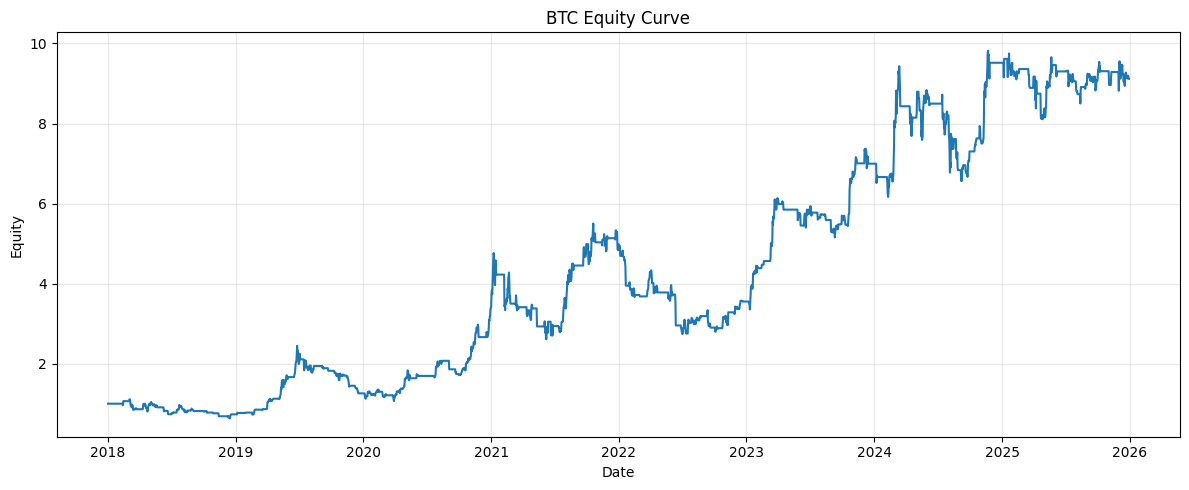

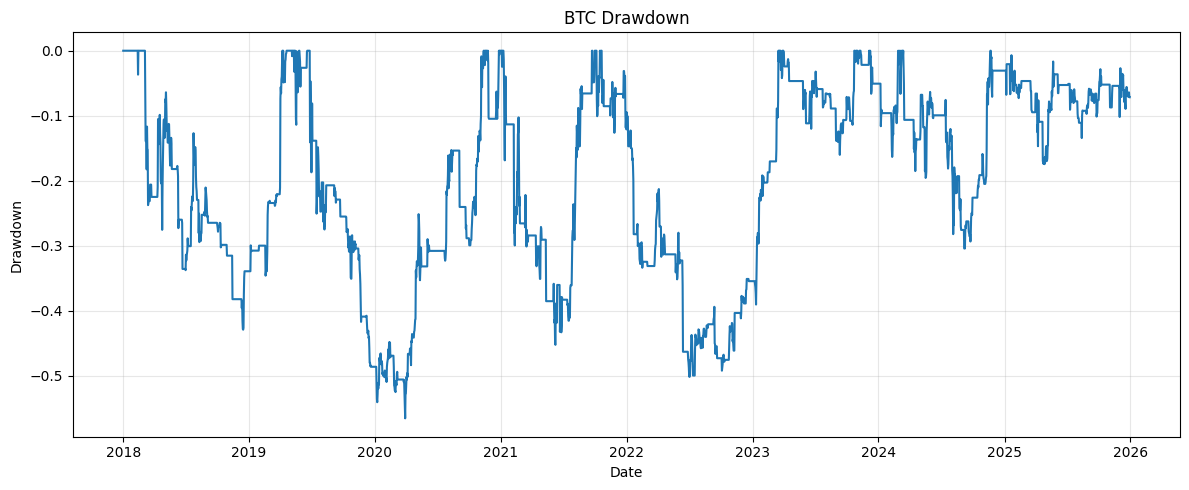

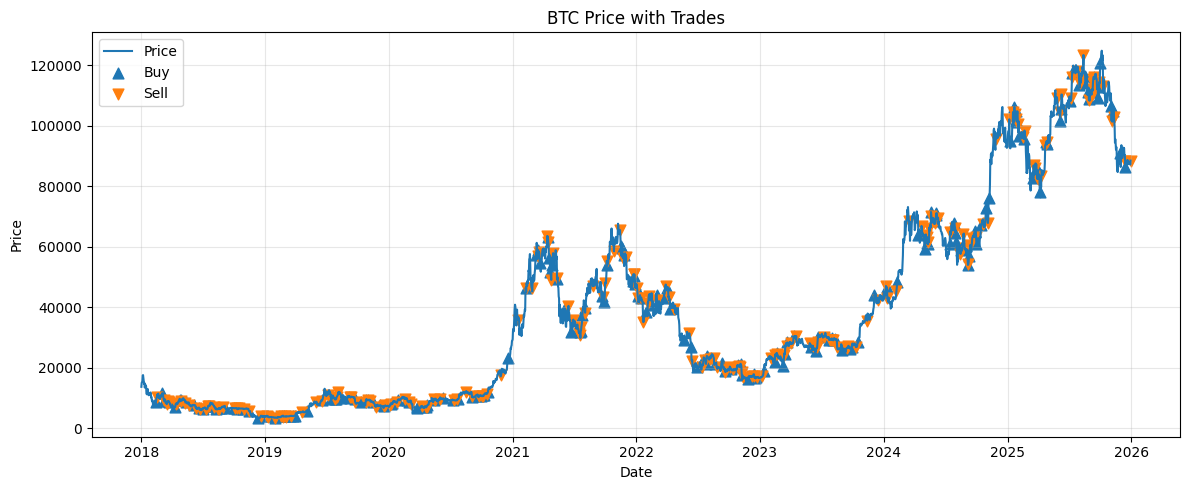

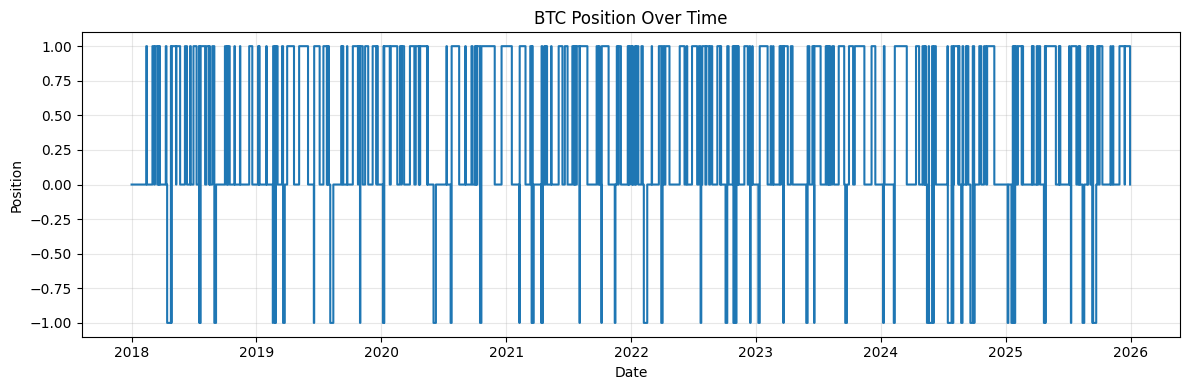

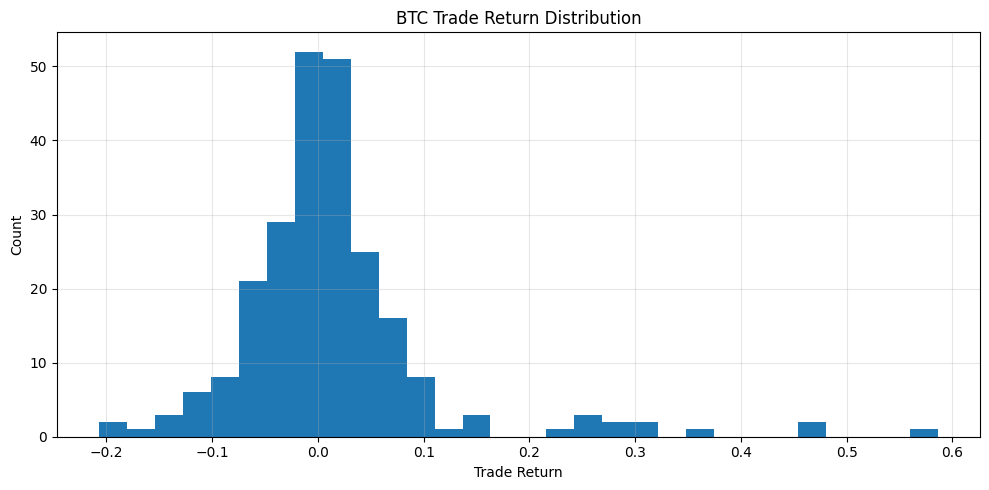

In [175]:
plot_equity_curve(btc_daily_eval, title="BTC Equity Curve")
plot_drawdown(btc_daily_eval, title="BTC Drawdown")
plot_price_with_trades(btc_daily_eval, title="BTC Price with Trades")
plot_position_over_time(btc_post, title="BTC Position Over Time")
plot_trade_return_histogram(btc_trade_log, title="BTC Trade Return Distribution")

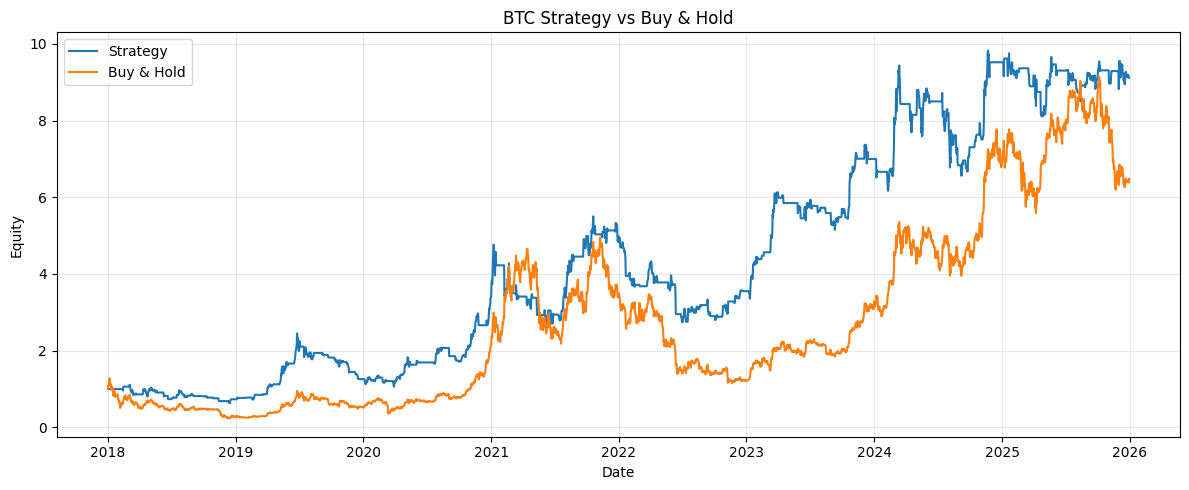

In [176]:
plot_strategy_vs_buy_hold(
    btc_daily_eval,
    title="BTC Strategy vs Buy & Hold"
)

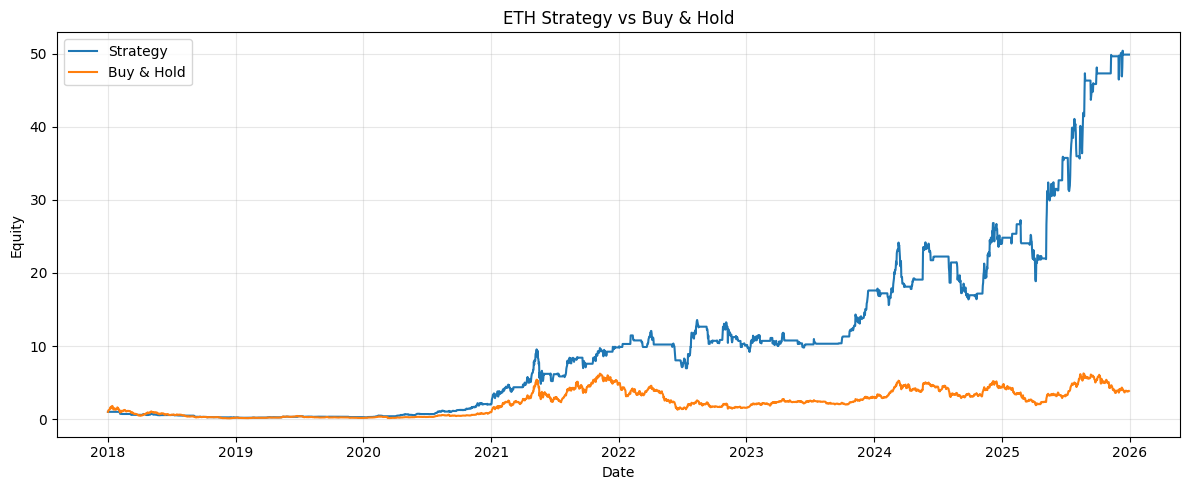

In [177]:
plot_strategy_vs_buy_hold(
    eth_daily_eval,
    title="ETH Strategy vs Buy & Hold"
)

In [181]:
# =========================
# BTC
# =========================
btc_macd_only = btc_combined.copy()
btc_macd_only['position'] = btc_macd_only['macd_position']
btc_macd_only['trade'] = btc_macd_only['position'].diff().fillna(0).clip(-1,1)

btc_boll_only = btc_combined.copy()
btc_boll_only['position'] = btc_boll_only['bollinger_position']
btc_boll_only['trade'] = btc_boll_only['position'].diff().fillna(0).clip(-1,1)

btc_daily_eval, btc_trade_log, btc_summary = evaluate_strategy_full(btc_post)
btc_macd_eval, _, btc_macd_summary = evaluate_strategy_full(btc_macd_only)
btc_boll_eval, _, btc_boll_summary = evaluate_strategy_full(btc_boll_only)


# =========================
# ETH
# =========================
eth_macd_only = eth_combined.copy()
eth_macd_only['position'] = eth_macd_only['macd_position']
eth_macd_only['trade'] = eth_macd_only['position'].diff().fillna(0).clip(-1,1)

eth_boll_only = eth_combined.copy()
eth_boll_only['position'] = eth_boll_only['bollinger_position']
eth_boll_only['trade'] = eth_boll_only['position'].diff().fillna(0).clip(-1,1)

eth_daily_eval, eth_trade_log, eth_summary = evaluate_strategy_full(eth_post)
eth_macd_eval, _, eth_macd_summary = evaluate_strategy_full(eth_macd_only)
eth_boll_eval, _, eth_boll_summary = evaluate_strategy_full(eth_boll_only)

In [182]:
cols = [
    "cumulative_pnl",
    "average_daily_pnl",
    "max_drawdown",
    "annualised_return",
    "sharpe_ratio_rf_3pct",
    "annualised_volatility"
]

In [183]:
btc_compare = pd.concat([
    pd.DataFrame(btc_summary, index=["Adaptive"]),
    pd.DataFrame(btc_macd_summary, index=["MACD"]),
    pd.DataFrame(btc_boll_summary, index=["Bollinger"])
])[cols]

btc_compare

,cumulative_pnl,average_daily_pnl,max_drawdown,annualised_return,sharpe_ratio_rf_3pct,annualised_volatility
Adaptive,8.116544,0.001012,-0.565173,0.318068,0.786548,0.431996
MACD,20.947787,0.001327,-0.563726,0.471013,1.021047,0.445369
Bollinger,-0.999997,-0.003923,-0.999997,-0.792390,-2.852977,0.512214


In [185]:
eth_compare = pd.concat([
    pd.DataFrame(eth_summary, index=["Adaptive"]),
    pd.DataFrame(eth_macd_summary, index=["MACD"]),
    pd.DataFrame(eth_boll_summary, index=["Bollinger"])
])[cols]

eth_compare

,cumulative_pnl,average_daily_pnl,max_drawdown,annualised_return,sharpe_ratio_rf_3pct,annualised_volatility
Adaptive,48.850704,0.001849,-0.820385,0.629807,1.055699,0.611395
MACD,53.419766,0.001842,-0.614735,0.647765,1.089449,0.590129
Bollinger,-1.000000,-0.005481,-1.000000,-0.895930,-2.911466,0.697227


In [186]:
btc_compare.sort_values("sharpe_ratio_rf_3pct", ascending=False)

,cumulative_pnl,average_daily_pnl,max_drawdown,annualised_return,sharpe_ratio_rf_3pct,annualised_volatility
MACD,20.947787,0.001327,-0.563726,0.471013,1.021047,0.445369
Adaptive,8.116544,0.001012,-0.565173,0.318068,0.786548,0.431996
Bollinger,-0.999997,-0.003923,-0.999997,-0.792390,-2.852977,0.512214


In [187]:
eth_compare.sort_values("sharpe_ratio_rf_3pct", ascending=False)

,cumulative_pnl,average_daily_pnl,max_drawdown,annualised_return,sharpe_ratio_rf_3pct,annualised_volatility
MACD,53.419766,0.001842,-0.614735,0.647765,1.089449,0.590129
Adaptive,48.850704,0.001849,-0.820385,0.629807,1.055699,0.611395
Bollinger,-1.000000,-0.005481,-1.000000,-0.895930,-2.911466,0.697227


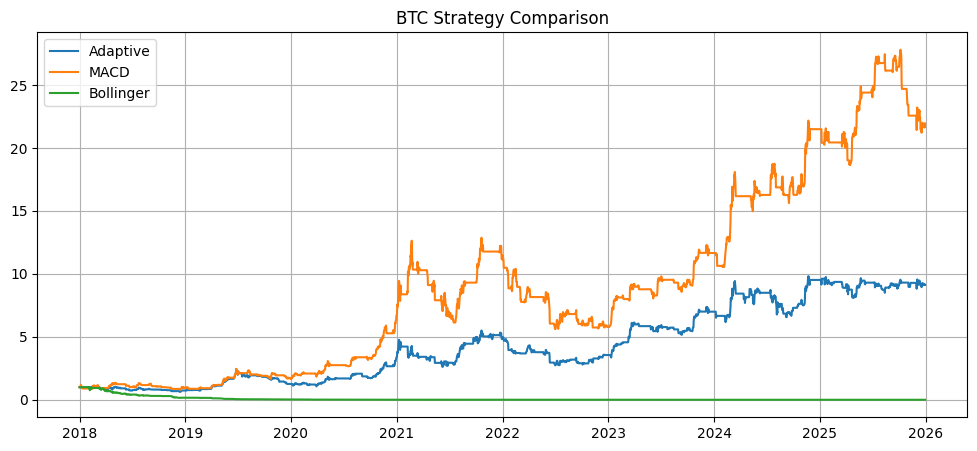

In [188]:
plt.figure(figsize=(12,5))
plt.plot(btc_daily_eval["date"], btc_daily_eval["equity_curve"], label="Adaptive")
plt.plot(btc_macd_eval["date"], btc_macd_eval["equity_curve"], label="MACD")
plt.plot(btc_boll_eval["date"], btc_boll_eval["equity_curve"], label="Bollinger")
plt.legend()
plt.title("BTC Strategy Comparison")
plt.grid(True)
plt.show()